## EDA for DDxPlus

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json


### Overview

In [2]:
df = pd.read_csv("../data/release_test_patients/release_test_patients.csv")
print("Dataset shape:", df.shape)


Dataset shape: (134529, 6)


In [3]:
display(df.head())

,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,49,"[['Bronchitis', 0.20230062181160519], ['GERD',...",F,GERD,"['E_53', 'E_54_@_V_112', 'E_54_@_V_161', 'E_54...",E_201
1,2,"[['Bronchospasm / acute asthma exacerbation', ...",M,Bronchitis,"['E_53', 'E_54_@_V_181', 'E_55_@_V_55', 'E_55_...",E_53
2,49,"[['Acute dystonic reactions', 0.62670508481658...",M,Acute dystonic reactions,"['E_15', 'E_128', 'E_147', 'E_168', 'E_172', '...",E_128
3,64,"[['Bronchitis', 0.2748608320637265], ['Acute l...",M,Acute laryngitis,"['E_48', 'E_49', 'E_53', 'E_54_@_V_181', 'E_55...",E_53
4,70,"[['URTI', 0.21257615919851483], ['Influenza', ...",F,URTI,"['E_41', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_201


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 134529 entries, 0 to 134528
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   AGE                     134529 non-null  int64
 1   DIFFERENTIAL_DIAGNOSIS  134529 non-null  str  
 2   SEX                     134529 non-null  str  
 3   PATHOLOGY               134529 non-null  str  
 4   EVIDENCES               134529 non-null  str  
 5   INITIAL_EVIDENCE        134529 non-null  str  
dtypes: int64(1), str(5)
memory usage: 6.2 MB


In [5]:
print("Missing values:")
print(df.isna().sum())


Missing values:
AGE                       0
DIFFERENTIAL_DIAGNOSIS    0
SEX                       0
PATHOLOGY                 0
EVIDENCES                 0
INITIAL_EVIDENCE          0
dtype: int64


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 101


### Age and Gender

In [7]:
df["AGE"] = pd.to_numeric(df["AGE"])
print("Age:")
print(df["AGE"].describe())


Age:
count    134529.000000
mean         39.773335
std          22.742966
min           0.000000
25%          22.000000
50%          39.000000
75%          56.000000
max         109.000000
Name: AGE, dtype: float64


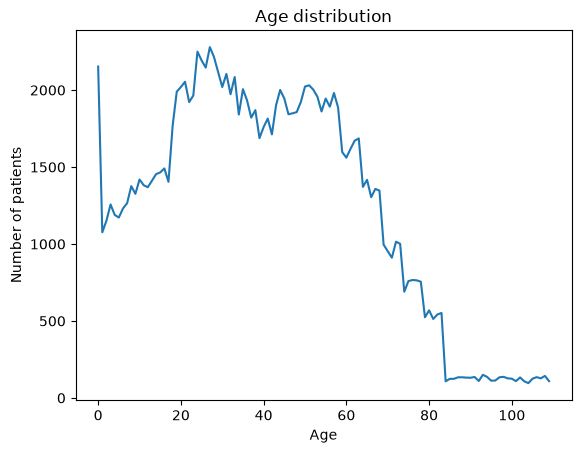

In [8]:
age_counts = df["AGE"].value_counts().sort_index()

plt.plot(age_counts.index, age_counts.values)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

In [9]:
print("Gender Percentages")
print(df["SEX"].value_counts(dropna=False)/len(df) *100)

Gender Percentages
SEX
F    51.544277
M    48.455723
Name: count, dtype: float64


<Axes: xlabel='SEX'>

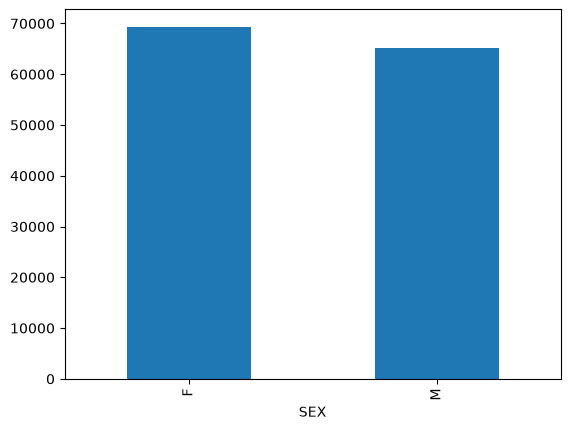

In [10]:
df["SEX"].value_counts().plot.bar()

### Diagnosis 

In [11]:
diagnosis_counts = df["PATHOLOGY"].value_counts()
print("Number of diagnosis:", df["PATHOLOGY"].nunique())


Number of diagnosis: 49


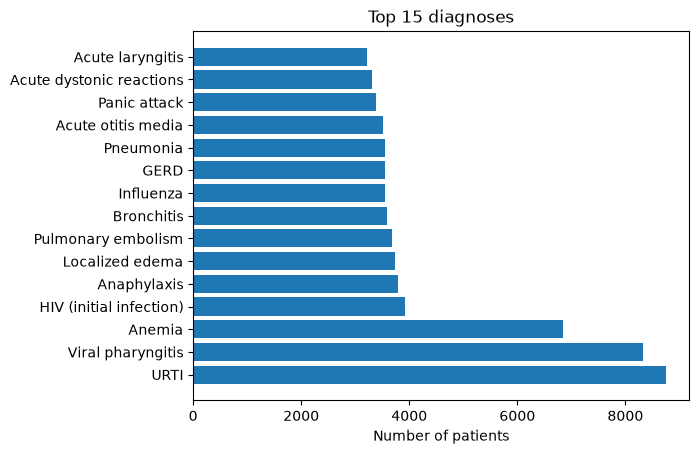

In [12]:
common = diagnosis_counts.head(15)

plt.barh(common.index, common.values)
plt.title("Top 15 diagnoses")
plt.xlabel("Number of patients")
plt.show()

### evidences

In [13]:
evidences = df["EVIDENCES"].str.strip("[]")
evidences = evidences.str.replace("'", "")
evidences = evidences.str.split(", ")

In [ ]:
allevidences = []

for items in evidences:
    cleaned = set()

    if isinstance(items, list):
        for item in items:
            evidence = item.split("_@_")[0]
            cleaned.add(evidence)

        allevidences.append(cleaned)
    else:
        allevidences.append(None)

allevidences = pd.Series(allevidences, index=df.index)

134529

In [ ]:
counts = {}

for items in allevidences:
    if items is not None:
        for evidence in items:
            counts[evidence] = counts.get(evidence, 0) + 1

evcounts = sorted(counts, reverse=True, key=counts.get)

for evidence in evcounts[:15]:
    print(evidence, counts[evidence])



E_204 134529
E_55 107960
E_57 107960
E_58 107960
E_59 107960
E_56 107960
E_54 107960
E_53 106581
E_66 52138
E_201 41553
E_79 38103
E_91 29121
E_136 27102
E_132 27102
E_135 27102


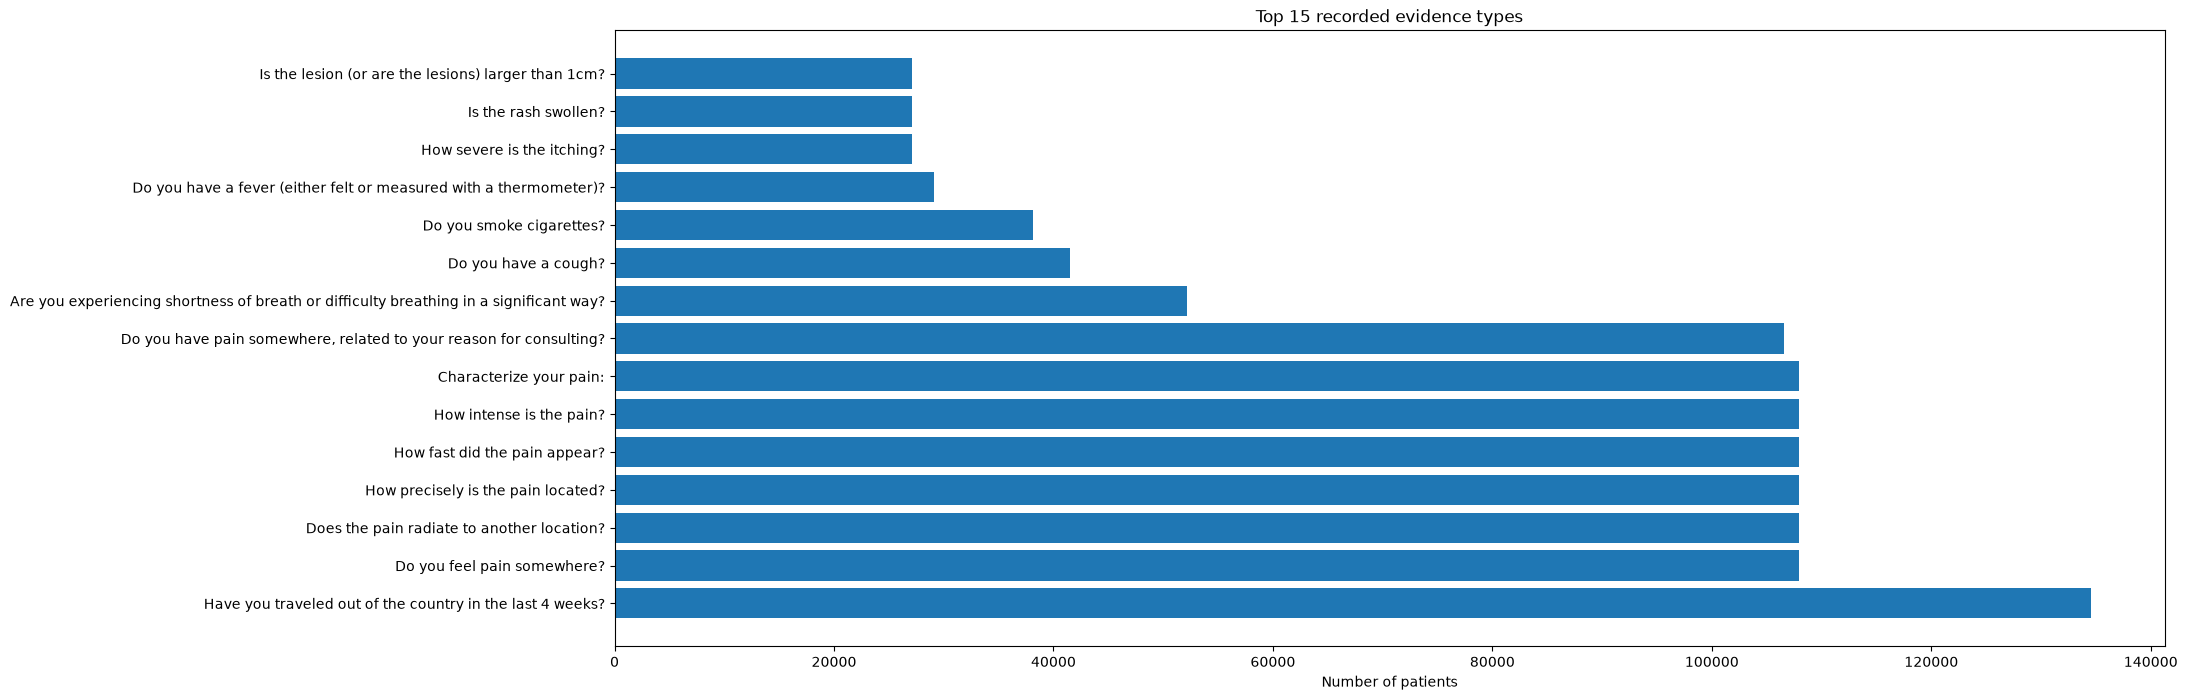

Number of symptoms in the dataset: 110
Number of antecedents in the dataset: 113


In [23]:

with open("../data/release_evidences.json", encoding="utf-8") as file:
    names = json.load(file)

top15 = evcounts[:15]
values = []
labels = []

for evidence in top15:
    values.append(counts[evidence])
    labels.append(names[evidence]["question_en"])

plt.figure(figsize=(20, 8))
plt.barh(labels, values)
plt.title("Top 15 recorded evidence types")
plt.xlabel("Number of patients")
plt.show()

total = 0

for evidence in counts:
    if names[evidence]["is_antecedent"] == False:
        total += 1

print("Number of symptoms in the dataset:", total)

total = 0

for evidence in counts:
    if names[evidence]["is_antecedent"] == True:
        total += 1

print("Number of antecedents in the dataset:", total)